<a href="https://colab.research.google.com/github/rpizarrog/Libro-Aprendizaje-Automatico.-Casos-de-Estudio-con-R-y-Python/blob/main/Python%20NoteBooks/Ejemplo_de_Correlacipn_y_multicolienalidad_de_ventas_totales.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Se construye un caso de estudio para ejemplificar la correlación y el postulado de multicolinealidad en Python. En notebook se puede recrfear en https://colab.research.google.com/drive/1gTPrQiFSGMzyIXbzshWxU6ipLD5t2t7A?usp=sharing.

Además se puede descargar y también emular en:
Los datos:

In [1]:
import pandas as pd

datos = pd.DataFrame({
    "clientes": [180, 200, 220, 250, 270, 300, 320, 350, 370, 400],
    "transacciones": [153.59, 176.55, 221.38, 226.06, 244.94, 295.73, 294.91, 296.02, 322.70, 353.32],
    "precio_promedio": [24.23, 22.85, 22.48, 24.96, 22.59, 22.96, 21.81, 22.16, 20.02, 19.03],
    "temperatura": [37.36, 33.49, 26.10, 34.10, 30.58, 28.80, 31.35, 28.92, 29.81, 30.12],
    "venta_total": [4480.29, 4949.43, 5366.43, 6114.52, 6633.10, 7389.74, 7901.46, 8449.76, 9099.71, 9911.82]
})

Correlación entre variables usando función directa de *.corr()* de biblioteca *seaborn* combinada con *matplotlib.pyplot*.


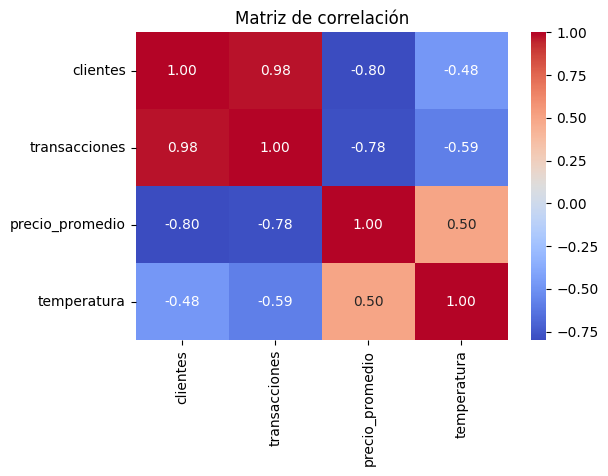

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt

corr = datos[["clientes", "transacciones", "precio_promedio", "temperatura"]].corr()

plt.figure(figsize=(6,4))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de correlación")
plt.show()

Mas elaborado usando funciones preparadas llamada *corrfunc()* que encapsulan bibliotecas de *seaborn* y *matplotlib*.

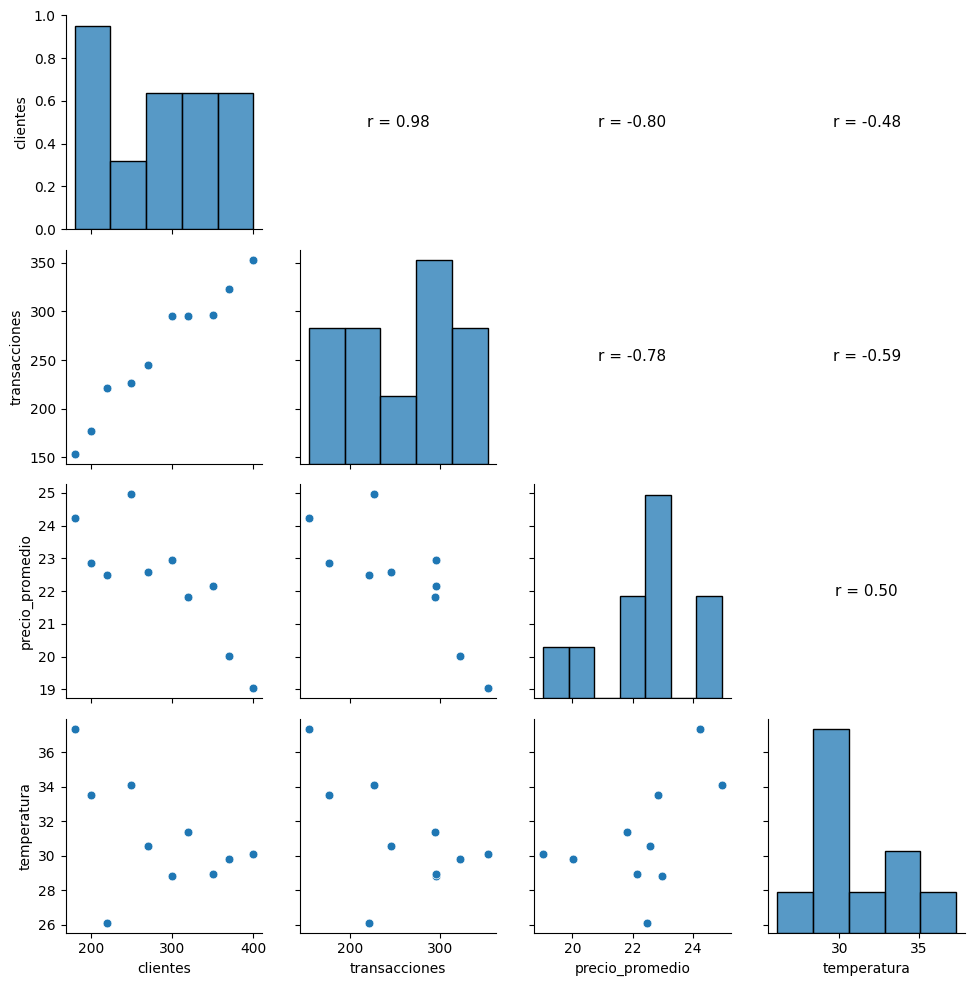

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

vars_ = ["clientes", "transacciones", "precio_promedio", "temperatura"]

# Función para mostrar r en el triángulo superior
def corrfunc(x, y, **kws):
    r = np.corrcoef(x, y)[0, 1]
    ax = plt.gca()
    ax.annotate(f"r = {r:.2f}",
                xy=(.5, .5), xycoords=ax.transAxes,
                ha='center', va='center', fontsize=11)
    ax.set_axis_off()

# Construcción del grid
g = sns.PairGrid(datos[vars_], diag_sharey=False)

# Triángulo inferior: dispersión
g.map_lower(sns.scatterplot, s=40)

# Diagonal: histogramas
g.map_diag(sns.histplot, kde=False)

# Triángulo superior: correlación
g.map_upper(corrfunc)

plt.show()

En las correlaciones se observa que existe una correlación muy alta entre el número o cantidad de clientes que compran identificado en la variable *clientes* y la cantidad de *transacciones*; por lo que se presume que la cantidad de clientes va en relación a la cantidad de transacciones.

Ahora, aquí en *Python* se puede calcular *VIF* sin construir el modelo, se puede  hacer uso de los valores ajustados de regresión lineal múltiple en donde venta total está en función de las demás variables *clientes*, *transacciones*, *precio_promedio* y *temperatura*; se incluye una constante o el coeficiente de intersección de la linea de tendencia.



In [4]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

X = datos[["clientes", "transacciones", "precio_promedio", "temperatura"]]

# AGREGAR CONSTANTE (CLAVE)
X = sm.add_constant(X)

vif = pd.DataFrame()
vif["Variable"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

          Variable         VIF
0            const  926.128311
1         clientes   38.247192
2    transacciones   39.877016
3  precio_promedio    3.051390
4      temperatura    2.452970


Se observa que los valores de *VIF* de las variables clientes y transacciones presentan colinealidad, por lo que se hará un mecanismo similar sumar ambos valores, siendo estos numéricos luego, volver a generar VIF e interpretar.

In [8]:
datos["clientes_transacciones"] = datos["clientes"] + datos["transacciones"]
X_new = datos[["clientes_transacciones", "precio_promedio", "temperatura"]]

X_new_const = sm.add_constant(X_new)

vif_new = pd.DataFrame()
vif_new["Variable"] = X_new_const.columns
vif_new["VIF"] = [variance_inflation_factor(X_new_const.values, i) for i in range(X_new_const.shape[1])]

print(vif_new)

                 Variable         VIF
0                   const  897.403508
1  clientes_transacciones    2.932928
2         precio_promedio    2.797738
3             temperatura    1.422728


Ahora ya no existe colinealidad.
